<a href="https://colab.research.google.com/github/tustus1022-ui/esaa/blob/main/ESAA_YB_WEEK13_transcription1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

파이썬 머신러닝 완벽가이드 ch7. 3-4 pg. 449~463

## **03. 평균이동**
### **평균 이동(Mean Shift)의 개요**
평균 이동(Mean Shift)은 K-평균과 유사하게 중심을 군집의 중심으로 지속적으로 움직이면서 군집화를 수행
- 하지만 K-평균이 중심에 소속된 데이터의 평균 거리 중심으로 이동하는 데 반해, 평균 이동은 중심을 데이터가 모여 있는 밀도가 가장 높은 곳으로 이동시킴
- 평균 이동 군집화는 데이터의 분포도를 이용해 군집 중심점을 찾는다. 군집 중심점은 데이터 포
인트가 모여있는 곳이라는 생각에서 착안한 것이며 이를 위해 확률 밀도 함수(probability density
function)를 이용함
- 주어진 모델의 확률 밀도 함수를 찾기 위해 KDE(Kernel Density Estimation)를 이용

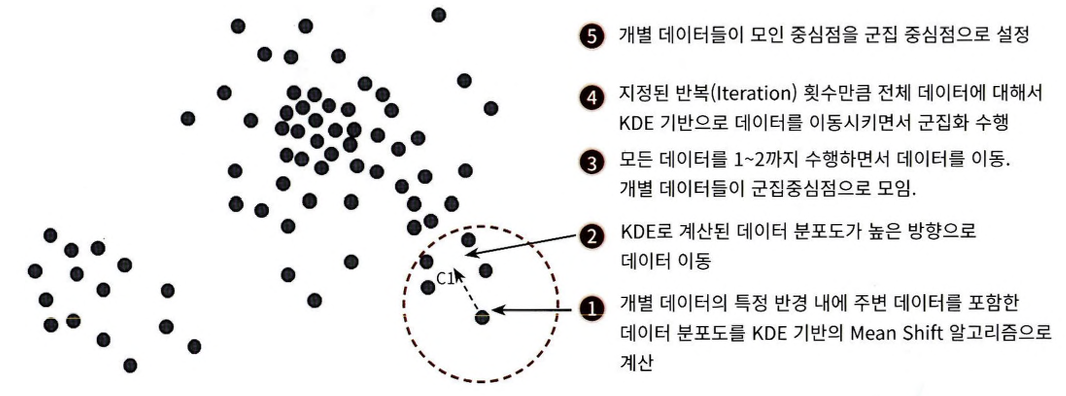

- KDE (Kernel Density Estimation)

커널 함수를 통해 어떤 변수의 확률 밀도 함수를 추정하는 대표적인 방법

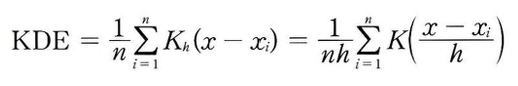

대역폭 h는 KDE 형태를 부드러운(또는 뾰족한) 형태로 평활화(Smoothing)하는 데 적용되며, 이 h를 어떻게 설정하느냐에 따라 확률 밀도 추정 성능을 크게 좌우할 수 있다.

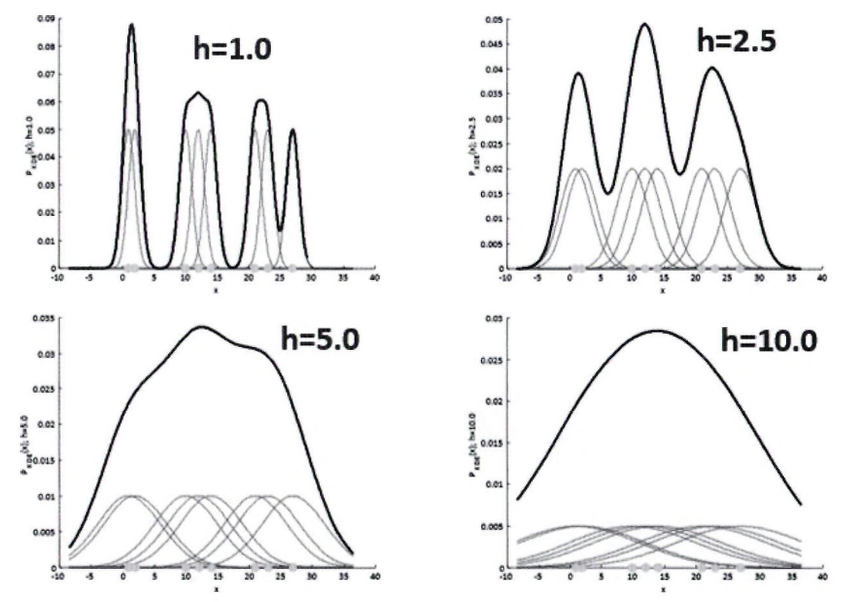

- 일반적으로 평균 이동 군집화는 대역폭이 클수록 평활화된 KDE로 인해 적은 수의 군집 중심점을 가지며 대역폭이 적을수록 많은 수의 군집 중심점을 가진다.
- 또한 평균 이동 군집화는 군집의 개수를 지정하지 않으며, 오직 대역폭의 크기에 따라 군집화를 수행한다.
- 사이킷런은 평균 이동 군집화를 위해
MeanShift 클래스를 제공한다.
- MeanShift 클래스의 가장 중요한 초기화 파라미터는 bandwidth이며 이 파라미터는 KDE의 대역폭 h와 동일
- 최적의 대역폭 계산을 위해 사이킷런은 estimate_bandwidth() 함수를 제공함

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X, y = make_blobs(
    n_samples=200,
    n_features=2,
    centers=3,
    cluster_std=0.7,
    random_state=0
)

meanshift = MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2 3 4 5]


In [2]:
meanshift = MeanShift(bandwidth=1)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


In [3]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
print('bandwidth 값:', round(bandwidth, 3))

bandwidth 값: 1.816


In [4]:
import pandas as pd

clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

# estimate_bandwidth()로 최적의 bandwidth 계산
best_bandwidth = estimate_bandwidth(X)

meanshift = MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


/tmp/ipykernel_731/1085495265.py:31: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


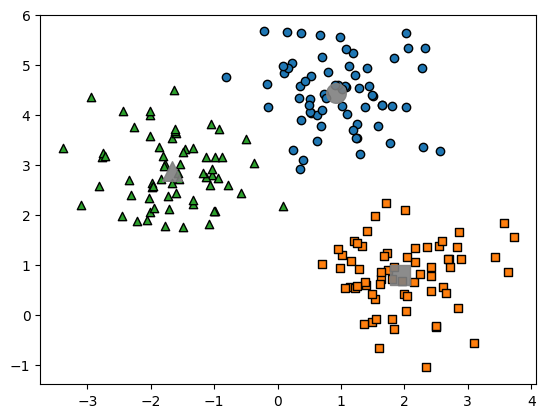

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

clusterDF['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = clusterDF[clusterDF['meanshift_label'] == label]
    center_x_y = centers[label]

    # 군집별로 다른 마커로 산점도 적용
    plt.scatter(
        x=label_cluster['ftr1'],
        y=label_cluster['ftr2'],
        edgecolor='k',
        marker=markers[label]
    )

    # 군집별 중심 표현
    plt.scatter(
        x=center_x_y[0],
        y=center_x_y[1],
        s=200,
        color='gray',
        alpha=0.9,
        marker=markers[label]
    )

    plt.scatter(
        x=center_x_y[0],
        y=center_x_y[1],
        s=70,
        color='k',
        edgecolor='k',
        marker='' % label
    )

plt.show()

In [6]:
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64


평균 이동의 장점은 데이터 세트의 형태를 특정 형태로 가정한다든가, 특정 분포도 기반의 모델로 가정하지 않기 때문에 좀 더 유연한 군집화가 가능한 것이다. 또한 이상치의 영향력도 크지 않으며, 미리 군집의 개수를 정할 필요도 없다.

하지만 알고리즘의 수행 시간이 오래 걸리고 무엇보다도 band- width의 크기에 따른 군집화 영향도가 매우 크다. 이 같은 특징 때문에 일반적으로 평균 이동 군집화 기법은 분석 업무 기반의 데이터 세트보다는 컴퓨터 비전 영역에서 더 많이 사용된다.

## **04. GMM (Gaussian Mixture Model)**
### **GMM (Gaussian Mixture Model) 소개**

GMM 군집화 : 군집화를 적용하고자 하는 데이터가 여러 개의 가우시안 분포(GaussianDistribution)를 가진 데이터 집합들이 섞여서 생성된 것이라는 가정하에 군집화를 수행하는 방식

GMM은 데이터를 여러 개의 가우시안 분포가 섞인 것으로 간주함. 섞인 데이터 분포에서 개별 유형의 가우시안 분포를 추출

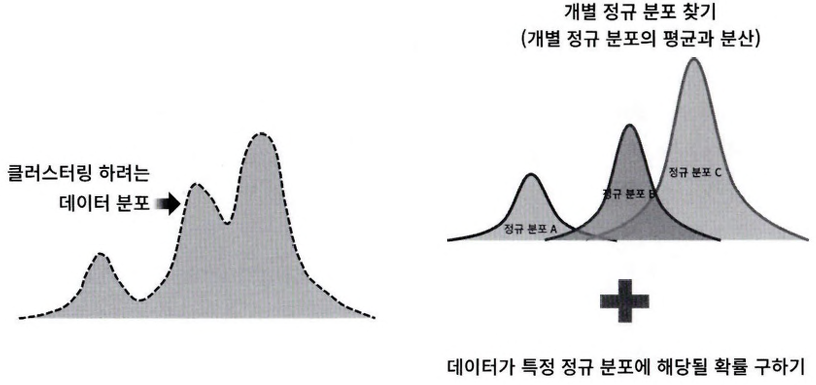

- 개별 정규 분포의 평균과 분산
- 각 데이터가 어떤 정규 분포에 해당되는지의 확률

이러한 모수 추정을 위해 GMM은 EM (Expectation and Maximization) 방법을 적용함
- 사이킷런은 이러한 GMM의 EM 방식을 통한 모수 추정 군집화를 지원하기 위해 GaussianMixture 클래스를 지원한다.

### **GMM을 이용한 붓꽃 데이터 세트 군집화**

GMM은 확률 기반 군집화이고 K-평균은 거리 기반 군집화이다. 이번에는 붓꽃 데이터 세트로 이 두 가지 방식을 이용해 군집화를 수행한 뒤 양쪽 방식을 비교해보자.

In [7]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 좀 더 편리한 데이터 handling을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
irisDF['target'] = iris.target

- GaussianMixture 객체의 가장 중요한 초기화 파라미터 : n_components : gaussian mixture의 모델의 총 개수

In [8]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

# 군집화 결과를 irisDF의 'gmm_cluster' 칼럼명으로 저장
irisDF['gmm_cluster'] = gmm_cluster_labels
irisDF['target'] = iris.target

# target 값에 따라 gmm_cluster 값이 어떻게 매핑됐는지 확인
iris_result = irisDF.groupby(['target'])['gmm_cluster'].value_counts()
print(iris_result)

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


Target 0은 cluster 0으로, Target 2는 duster 1 로 모두 잘 매핑됨. Target 1만 cluster 2로 45개(90%), cluster 1로 5개(10%) 매핑됐다.

앞 절의 붓꽃 데이터 세트의 K-평균 군집화 결과보다 더 효과적인 분류 결과가 도출됨

In [9]:
# 붓꽃 데이터 세트의 K-평균 군집화를 수행한 결과
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)

irisDF['kmeans_cluster'] = kmeans_cluster_labels

iris_result = irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


이는 어떤 알고리즘에 더 뛰어나다는 의미가 아니라 붓꽃 데이터 세트가 GMM 군집화에 더 효과적이라는 의미이다. K-평균은 평균 거리 중심으로 중심을 이동하면서 군집화를 수행하는 방식이므로 개별 군집 내의 데이터가 원형으로 흩어져 있는 경우에 매우 효과적으로 군집화가 수행될 수 있다.

### **GMM과 K-평균의 비교**

- KMeans는 원형의 범위에서 군집화를 수행한다. 데이터 세트가 원형의 범위를 가질수록 KMeans의
군집화 효율은 더욱 높아진다.

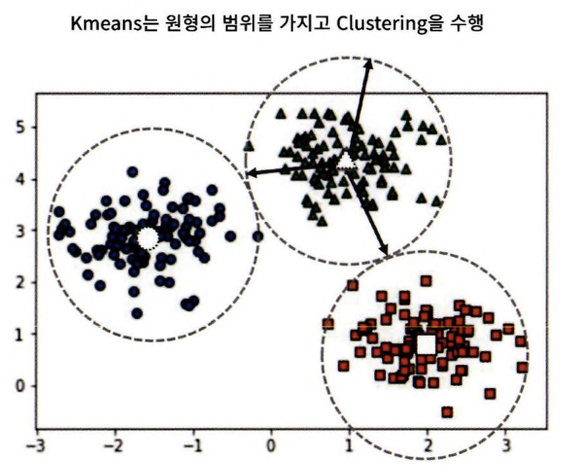

- 군집을 자주 시각화하므로 이를 위한 별도의 함수
를 만들어 이용하겠다.
- 함수명 : visualize_cluster_plot(clusterobj, dataframe, label_name, iscluster=True)
- clusterobj : 사이킷런의 군집 수행 객체. KMeans나 GaussiarWixture의 fit( )와 predict( )로 군집화를 완료한 객체. 만약 군집화 결과 시각화가 아니고 make_blobs()로 생성한 데이터의 시각화일 경우 None 입력
- dataframe : 피처 데이터 세트와 label 값을 가진 DataFrame
- label_name : 군집화 결과 시각화일 경우 dataframe 내의 군집화 label 칼럼명, make_blobs( ) 결과 시각화일 경우는 dataframe 내의 target 칼럼명
- iscenter : 사이킷런 Cluster 객체가 군집 중심 좌표를 제공하면 True, 그렇지 않으면 False

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import make_blobs

%matplotlib inline


def visualize_cluster_plot(cluster_result=None, dataframe=None, label_name='target', iscenter=True):
    if dataframe is None:
        print("Error: DataFrame is required.")
        return

    unique_labels = np.unique(dataframe[label_name])
    markers = ['o', 's', '^', 'x', '*', 'D', '+', 'v', '<', '>']

    for label in unique_labels:
        label_cluster = dataframe[dataframe[label_name] == label]

        plt.scatter(
            x=label_cluster['ftr1'],
            y=label_cluster['ftr2'],
            edgecolor='k',
            marker=markers[label % len(markers)]
        )

        if iscenter and cluster_result is not None and hasattr(cluster_result, 'cluster_centers_'):
            center_x_y = cluster_result.cluster_centers_[label]

            plt.scatter(
                x=center_x_y[0],
                y=center_x_y[1],
                s=200,
                color='gray',
                alpha=0.9,
                marker=markers[label % len(markers)]
            )

            plt.scatter(
                x=center_x_y[0],
                y=center_x_y[1],
                s=70,
                color='k',
                edgecolor='k',
                marker='' % label
            )

    plt.show()

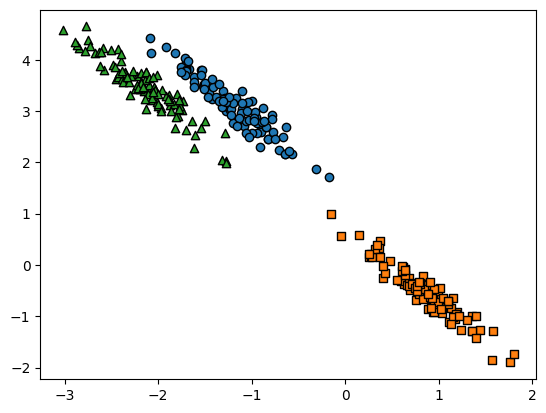

In [11]:
from sklearn.datasets import make_blobs

# make_blobs()로 300개의 데이터 세트, 3개의 군집 세트, cluster_std=0.5로 만듦
X, y = make_blobs(
    n_samples=300,
    n_features=2,
    centers=3,
    cluster_std=0.5,
    random_state=0
)

# 길게 늘어난 타원형의 데이터 세트를 생성하기 위해 변환함
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X_aniso = np.dot(X, transformation)

# feature 데이터 세트와 make_blobs()의 y 결과값을 DataFrame으로 저장
clusterDF = pd.DataFrame(data=X_aniso, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

# 생성된 데이터 세트를 target별로 다른 마커로 표시해 시각화
visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

위와 같이 만들어진 데이터 세트에서는 KMeans의 군집화 정확성이 떨어지게 된다.

/tmp/ipykernel_731/4116085222.py:40: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


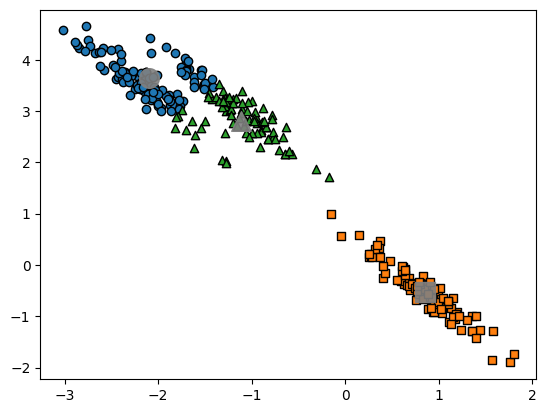

In [12]:
# KMeans가 위 데이터 세트를 어떻게 군집화하는지 확인

# 3개의 군집 기반 KMeans를 X_aniso 데이터 세트에 적용
kmeans = KMeans(3, random_state=0)
kmeans_label = kmeans.fit_predict(X_aniso)

clusterDF['kmeans_label'] = kmeans_label

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_label', iscenter=True)

KMeans로 군집화를 수행할 경우, 주로 원형 영역 위치로 개별 군집화가 되면서 원하는 방향으로 구성되지 않음을 알 수 있다. KMeans가 평균 거리 기반으로 군집화를 수행하므로 같은 거리상 원형으로 군집을 구성하면서 위와 같이 길쭉한 방향으로 데이터가 밀접해 있을 경우에는 최적의 군집화가 어렵다.

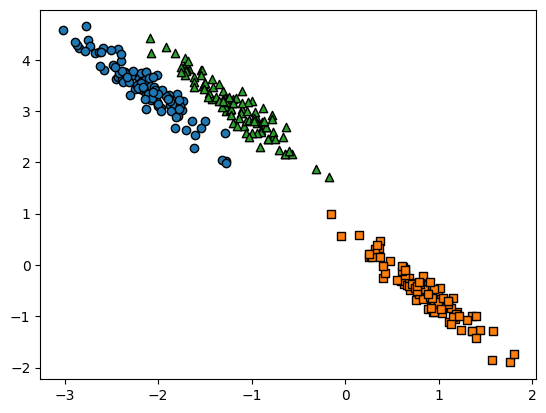

In [13]:
# GMM으로 군집화 수행

# 3개의 n_components 기반 GMM을 X_aniso 데이터 세트에 적용
gmm = GaussianMixture(n_components=3, random_state=0)
gmm_label = gmm.fit(X_aniso).predict(X_aniso)

clusterDF['gmm_label'] = gmm_label

# GaussianMixture는 cluster_centers_ 속성이 없으므로 iscenter를 False로 설정
visualize_cluster_plot(gmm, clusterDF, 'gmm_label', iscenter=False)

데이터가 분포된 방향에 따라 정확하게 군집화됐음을 알 수 있다. GMM은 K-평균과 다르게 군집의 중심 좌표를 구할 수 없기 때문에 군집 중심 표현이 visualize_cluster_plot( )에서 시각화되지 않는다.

In [14]:
#  make_blobs()의 target 값과 KMeans, GMM의 군집 Label 값을 서로 비교해
# 위와 같은 데이터 세트에서 얼만큼의 군집화 효율 차이가 발생하는지 확인

print('### KMeans Clustering ###')
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

print('\n### Gaussian Mixture Clustering ###')
print(clusterDF.groupby('target')['gmm_label'].value_counts())

### KMeans Clustering ###
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64

### Gaussian Mixture Clustering ###
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64


KMeans의 경우 군집 1 번만 정확히 매핑됐지만, 나머지 군집의 경우 target 값과 어긋나는 경우가 발생하고 있다. 하지만 GMM의 경우는 군집이 target 값과 잘 매핑돼 있다.

이처럼 GMM의 경우는 KMeans보다 유연하게 다양한 데이터 세트에 잘 적용될 수 있다는 장점이 있다. 하지만 군집화를 위한 수행 시간이 오래 걸린다는 단점이 있다.